# Benchmark 3P Clean: DVN depth-2, DVN depth-3, Greedy, Random

Plan:
- benchmark principal: `DVN depth-2` vs `Greedy depth-2` vs `Random`
- benchmark separe: `DVN depth-3` vs `Greedy depth-3` vs `Random`
- comparaison ajustee `DVN d2` vs `DVN d3`

In [1]:
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

src_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists()), None)
if src_path is None:
    raise FileNotFoundError("Could not find a 'src' directory.")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from src.blockblast.block_blast_3p_env import BlockBlast3PEnv
from src.dvn.agent import DVNAgent1P
from src.dvn.models import BlockBlastValueNet1PmultikernelFlattenned, BlockBlastValueNet1P

print(f'Root: {src_path}')

Root: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project


In [2]:
# Config
CHECKPOINT = src_path / 'final_weights' / 'dvn_final_20260313_020137.pt'

EPISODES_MAIN = 250
EPISODES_D3 = 25
MAX_STEPS = 1000
SEED = 123
GAMMA = 0.99
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

PLOT_CAP = 20000
BOOTSTRAP_B = 1000

out_dir = src_path / 'plots'
out_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f'Device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT}')
print(f'EPISODES_MAIN={EPISODES_MAIN}, EPISODES_D3={EPISODES_D3}')

Device: cuda
Checkpoint: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/final_weights/dvn_final_20260313_020137.pt
EPISODES_MAIN=250, EPISODES_D3=25


In [3]:
# Load DVN model
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
policy_keys = set(checkpoint['policy_state_dict'].keys())
model_cls = BlockBlastValueNet1PmultikernelFlattenned if any(k.startswith('branches.') for k in policy_keys) else BlockBlastValueNet1P

agent = DVNAgent1P(policy_net=model_cls, device=DEVICE)
agent.policy_net.load_state_dict(checkpoint['policy_state_dict'])
agent.target_net.load_state_dict(checkpoint['target_state_dict'])
agent.policy_net.eval()
agent.target_net.eval()

print('Model loaded:', model_cls.__name__)

Model loaded: BlockBlastValueNet1PmultikernelFlattenned


In [ ]:
# Policies / helpers
def _dvn_value_batch(agent, boards, batch_size=256):
    if len(boards) == 0:
        return np.array([], dtype=np.float32)
    boards_np = np.asarray(boards, dtype=np.float32)
    values = []
    for start in range(0, len(boards_np), batch_size):
        chunk = torch.from_numpy(boards_np[start:start + batch_size]).to(agent.device)
        with torch.inference_mode():
            values.append(agent.policy_net(chunk).squeeze(-1).cpu().numpy())
    return np.concatenate(values).astype(np.float32, copy=False)


def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys


def random_action(env, rng):
    valid = np.flatnonzero(env.valid_placements.reshape(-1).astype(bool))
    return int(rng.choice(valid)) if valid.size > 0 else None


def greedy_depth2_action(env):
    g = env.grid_size
    n = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_actions = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions.size == 0:
        return None

    best_total, best_a = -np.inf, int(valid_actions[0])
    for action in valid_actions:
        piece_idx = int(action // (g * g))
        row, col = divmod(int(action % (g * g)), g)

        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, piece_idx, row, col)
        pieces_used1 = env.pieces_used.copy()
        pieces_used1[piece_idx] = 1
        remaining1 = [i for i in range(n) if not pieces_used1[i]]

        if not remaining1:
            total = float(r0)
        else:
            best_r1 = -np.inf
            for p1 in remaining1:
                valid1 = env._valid_positions_for_piece_on_board(board1, p1)
                rows1, cols1 = np.nonzero(valid1)
                for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                    _, r1, _ = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)
                    if r1 > best_r1:
                        best_r1 = r1
            total = float(r0) + (best_r1 if best_r1 > -np.inf else 0.0)

        if total > best_total:
            best_total, best_a = total, int(action)

    return best_a


def dvn_depth2_action(env, agent, gamma=0.99):
    g = env.grid_size
    n = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_actions = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions.size == 0:
        return None

    eval_boards = []
    r0_per_l0 = []
    meta = []

    for action in valid_actions:
        piece_idx = int(action // (g * g))
        pos = int(action % (g * g))
        row, col = divmod(pos, g)

        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, piece_idx, row, col)
        r0_per_l0.append(float(r0))

        pieces_used1 = env.pieces_used.copy()
        pieces_used1[piece_idx] = 1
        remaining = [i for i in range(n) if not pieces_used1[i]]

        if not remaining:
            idx = len(eval_boards)
            eval_boards.append(board1.astype(np.float32))
            meta.append(('d1', idx))
        else:
            start = len(eval_boards)
            l1_rewards = []
            for p1 in remaining:
                valid1 = env._valid_positions_for_piece_on_board(board1, p1)
                rows1, cols1 = np.nonzero(valid1)
                for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                    board2, r1, _ = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)
                    eval_boards.append(board2.astype(np.float32))
                    l1_rewards.append(float(r1))

            count = len(eval_boards) - start
            if count == 0:
                idx = len(eval_boards)
                eval_boards.append(board1.astype(np.float32))
                meta.append(('d1', idx))
            else:
                meta.append(('d2', start, count, np.array(l1_rewards, dtype=np.float32)))

    if not eval_boards:
        return int(valid_actions[0])

    v_all = _dvn_value_batch(agent, eval_boards, batch_size=256)

    q0 = np.empty(len(valid_actions), dtype=np.float32)
    for i, m in enumerate(meta):
        r0 = r0_per_l0[i]
        if m[0] == 'd1':
            q0[i] = r0 + gamma * float(v_all[m[1]])
        else:
            _, start, count, r1_arr = m
            q1 = r1_arr + gamma * v_all[start:start + count]
            q0[i] = r0 + gamma * float(np.max(q1))

    return int(valid_actions[int(np.argmax(q0))])


def greedy_depth3_action(env):
    g = env.grid_size
    n = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_actions0 = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions0.size == 0:
        return None

    best_total, best_action = -np.inf, int(valid_actions0[0])
    for a0 in valid_actions0:
        p0 = int(a0 // (g * g))
        row0, col0 = divmod(int(a0 % (g * g)), g)
        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, p0, row0, col0)

        used1 = env.pieces_used.copy()
        used1[p0] = 1
        rem1 = [i for i in range(n) if not used1[i]]

        if not rem1:
            total0 = float(r0)
        else:
            best_l1 = -np.inf
            for p1 in rem1:
                valid1 = env._valid_positions_for_piece_on_board(board1, p1)
                rows1, cols1 = np.nonzero(valid1)
                for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                    board2, r1, combo2 = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)

                    used2 = used1.copy()
                    used2[p1] = 1
                    rem2 = [i for i in range(n) if not used2[i]]

                    if not rem2:
                        score1 = float(r1)
                    else:
                        best_l2 = -np.inf
                        for p2 in rem2:
                            valid2 = env._valid_positions_for_piece_on_board(board2, p2)
                            rows2, cols2 = np.nonzero(valid2)
                            for r2v, c2v in zip(rows2.tolist(), cols2.tolist()):
                                _, r2, _ = env._simulate_one_hyp_step(board2, combo2, p2, r2v, c2v)
                                if r2 > best_l2:
                                    best_l2 = r2
                        score1 = float(r1) + (best_l2 if best_l2 > -np.inf else 0.0)

                    if score1 > best_l1:
                        best_l1 = score1

            total0 = float(r0) + (best_l1 if best_l1 > -np.inf else 0.0)

        if total0 > best_total:
            best_total, best_action = total0, int(a0)

    return best_action


def dvn_depth3_action(env, agent, gamma=0.99, batch_size=256):
    g = env.grid_size
    n = env.n_pieces
    board0 = env.board
    combo0 = int(env.combo)

    valid_actions0 = np.flatnonzero(env.valid_placements.reshape(-1))
    if valid_actions0.size == 0:
        return None

    leaf_boards = []
    l0_entries = []
    l0_fallback = {}

    for idx_a0, a0 in enumerate(valid_actions0):
        p0 = int(a0 // (g * g))
        row0, col0 = divmod(int(a0 % (g * g)), g)
        board1, r0, combo1 = env._simulate_one_hyp_step(board0, combo0, p0, row0, col0)

        used1 = env.pieces_used.copy()
        used1[p0] = 1
        rem1 = [i for i in range(n) if not used1[i]]

        if not rem1:
            l0_fallback[idx_a0] = float(r0)
            continue

        r1_list = []
        r2_list = []
        leaf_start = len(leaf_boards)

        for p1 in rem1:
            valid1 = env._valid_positions_for_piece_on_board(board1, p1)
            rows1, cols1 = np.nonzero(valid1)
            for r1v, c1v in zip(rows1.tolist(), cols1.tolist()):
                board2, r1, combo2 = env._simulate_one_hyp_step(board1, combo1, p1, r1v, c1v)

                used2 = used1.copy()
                used2[p1] = 1
                rem2 = [i for i in range(n) if not used2[i]]

                if not rem2:
                    leaf_boards.append(board2.astype(np.float32))
                    r1_list.append(float(r1))
                    r2_list.append(0.0)
                else:
                    for p2 in rem2:
                        valid2 = env._valid_positions_for_piece_on_board(board2, p2)
                        rows2, cols2 = np.nonzero(valid2)
                        for r2v, c2v in zip(rows2.tolist(), cols2.tolist()):
                            board3, r2, _ = env._simulate_one_hyp_step(board2, combo2, p2, r2v, c2v)
                            leaf_boards.append(board3.astype(np.float32))
                            r1_list.append(float(r1))
                            r2_list.append(float(r2))

        leaf_count = len(leaf_boards) - leaf_start
        if leaf_count == 0:
            l0_fallback[idx_a0] = float(r0)
        else:
            l0_entries.append((idx_a0, float(r0), np.array(r1_list, dtype=np.float32), np.array(r2_list, dtype=np.float32), leaf_start, leaf_count))

    v_leaf = _dvn_value_batch(agent, leaf_boards, batch_size=batch_size) if leaf_boards else np.array([], dtype=np.float32)

    q0 = np.full(len(valid_actions0), -np.inf, dtype=np.float32)
    for idx_a0, r0 in l0_fallback.items():
        q0[idx_a0] = float(r0)

    for idx_a0, r0, r1_arr, r2_arr, start, count in l0_entries:
        v = v_leaf[start:start + count]
        q_leaf = r2_arr + gamma * v
        q_l1 = r1_arr + gamma * q_leaf
        q0[idx_a0] = r0 + gamma * float(np.max(q_l1))

    return int(valid_actions0[int(np.argmax(q0))])


def run_eval(policy_name, action_fn, episodes, seed_offset):
    env = BlockBlast3PEnv(lookahead_gamma=GAMMA)
    returns, lengths = [], []

    for ep in tqdm(range(episodes), desc=policy_name):
        env.reset(seed=SEED + seed_offset + ep)
        total, step = 0.0, 0
        for step in range(MAX_STEPS):
            action = action_fn(env)
            if action is None:
                break
            _, r, terminated, truncated, _ = env.step(action)
            total += float(r)
            if terminated or truncated:
                break
        returns.append(total)
        lengths.append(step + 1)

    returns = np.asarray(returns, dtype=np.float32)
    lengths = np.asarray(lengths, dtype=np.int32)
    print(f"{policy_name:16s} | n={len(returns):4d} | reward mean={returns.mean():9.2f} std={returns.std():9.2f} | len mean={lengths.mean():7.2f}")
    return returns, lengths


## 1) Benchmark principal: DVN depth-2 vs Greedy depth-2 vs Random

In [5]:
rng_main = np.random.default_rng(seed=SEED)

dvn_returns, dvn_lengths = run_eval(
    'DVN depth-2',
    lambda env: dvn_depth2_action(env, agent, gamma=GAMMA),
    episodes=EPISODES_MAIN,
    seed_offset=0,
)

g2_returns, g2_lengths = run_eval(
    'Greedy depth-2',
    greedy_depth2_action,
    episodes=EPISODES_MAIN,
    seed_offset=10_000,
)

rnd_returns, rnd_lengths = run_eval(
    'Random',
    lambda env: random_action(env, rng_main),
    episodes=EPISODES_MAIN,
    seed_offset=20_000,
)

DVN depth-2:   0%|          | 0/250 [00:00<?, ?it/s]

DVN depth-2      | n= 250 | reward mean= 23412.72 std= 30429.17 | len mean= 209.29


Greedy depth-2:   0%|          | 0/250 [00:00<?, ?it/s]

Greedy depth-2   | n= 250 | reward mean=  1884.90 std=  2860.58 | len mean=  44.45


Random:   0%|          | 0/250 [00:00<?, ?it/s]

Random           | n= 250 | reward mean=    25.33 std=    42.92 | len mean=  11.93


Saved: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_main_20260315_163056.png


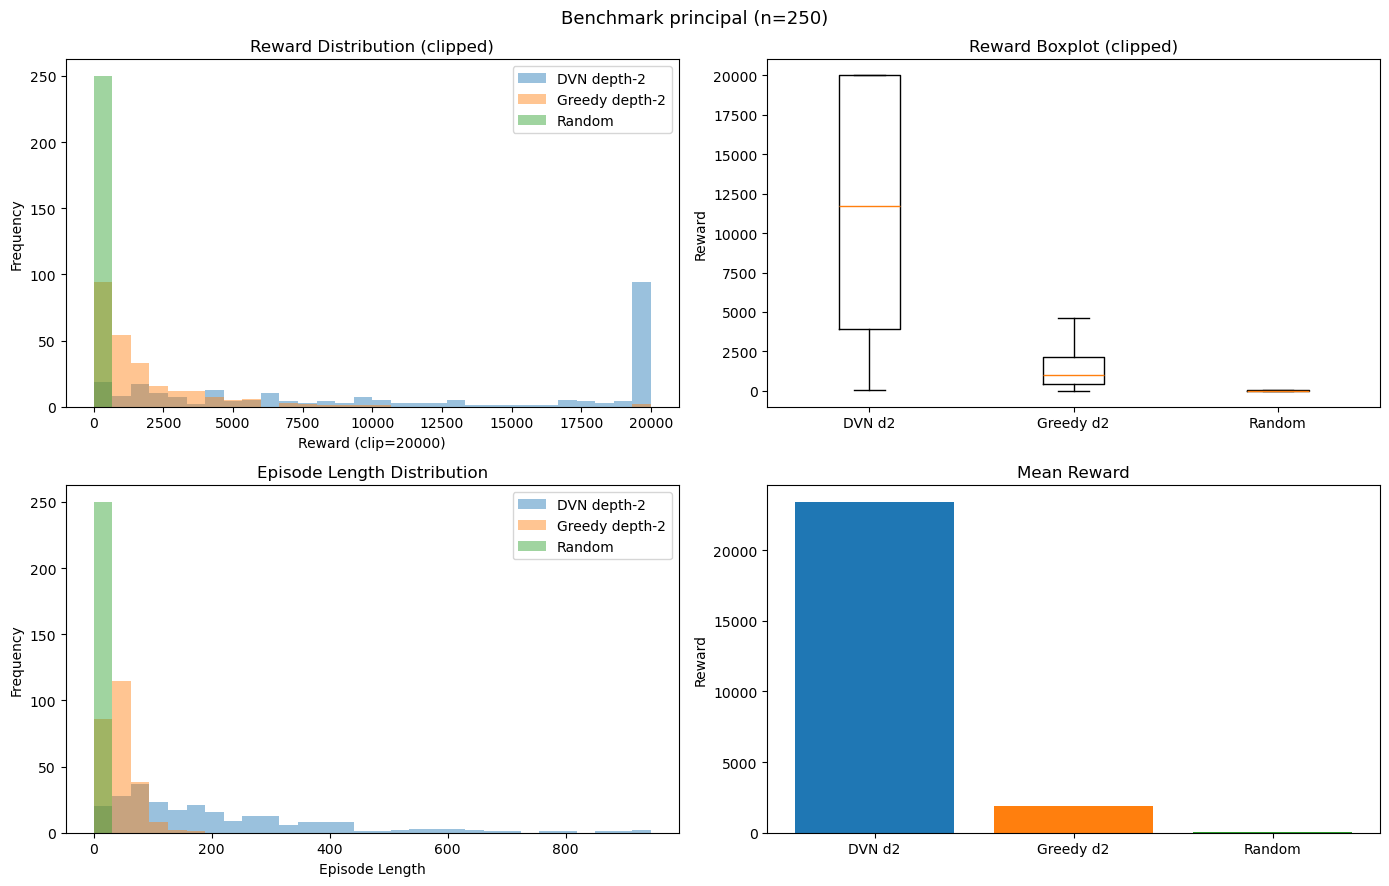

In [6]:
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

dvn_plot = np.clip(dvn_returns, 0, PLOT_CAP)
g2_plot = np.clip(g2_returns, 0, PLOT_CAP)
rnd_plot = np.clip(rnd_returns, 0, PLOT_CAP)

reward_bins = np.linspace(0, PLOT_CAP, 31)
length_max = max(int(np.max(dvn_lengths)), int(np.max(g2_lengths)), int(np.max(rnd_lengths)))
length_bins = np.linspace(0, length_max, 31)

ax = axes[0, 0]
ax.hist(dvn_plot, bins=reward_bins, alpha=0.45, label='DVN depth-2')
ax.hist(g2_plot, bins=reward_bins, alpha=0.45, label='Greedy depth-2')
ax.hist(rnd_plot, bins=reward_bins, alpha=0.45, label='Random')
ax.set_title('Reward Distribution (clipped)')
ax.set_xlabel(f'Reward (clip={PLOT_CAP})')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[0, 1]
ax.boxplot([dvn_plot, g2_plot, rnd_plot], tick_labels=['DVN d2', 'Greedy d2', 'Random'], showfliers=False)
ax.set_title('Reward Boxplot (clipped)')
ax.set_ylabel('Reward')

ax = axes[1, 0]
ax.hist(dvn_lengths, bins=length_bins, alpha=0.45, label='DVN depth-2')
ax.hist(g2_lengths, bins=length_bins, alpha=0.45, label='Greedy depth-2')
ax.hist(rnd_lengths, bins=length_bins, alpha=0.45, label='Random')
ax.set_title('Episode Length Distribution')
ax.set_xlabel('Episode Length')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1, 1]
means = [float(np.mean(dvn_returns)), float(np.mean(g2_returns)), float(np.mean(rnd_returns))]
labels = ['DVN d2', 'Greedy d2', 'Random']
ax.bar(labels, means, color=['C0', 'C1', 'C2'])
ax.set_title('Mean Reward')
ax.set_ylabel('Reward')

plt.suptitle(f'Benchmark principal (n={EPISODES_MAIN})', fontsize=13)
plt.tight_layout()

fig_main = out_dir / f'benchmark_3p_clean_main_{timestamp}.png'
plt.savefig(fig_main, dpi=150)
print(f'Saved: {fig_main}')
plt.show()

Saved: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_main_unclipped_20260315_163056.png


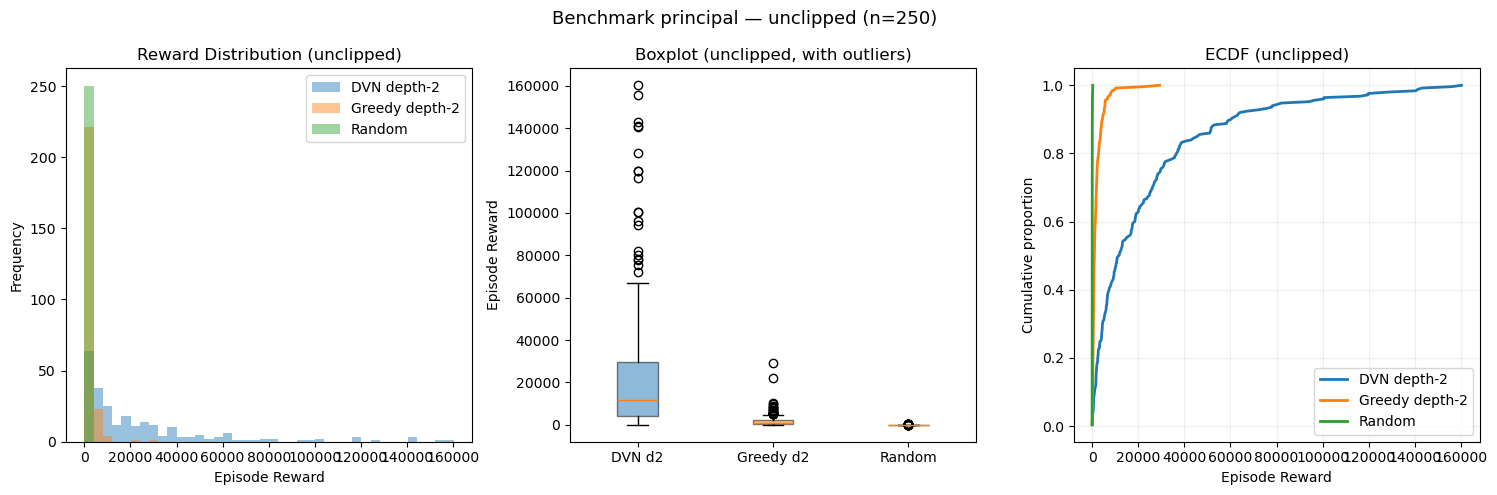

In [14]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

all_d2 = np.concatenate([dvn_returns, g2_returns, rnd_returns])
bins_unc = np.linspace(float(all_d2.min()), float(all_d2.max()), 41)

ax = axes[0]
ax.hist(dvn_returns, bins=bins_unc, alpha=0.45, label='DVN depth-2', color='C0')
ax.hist(g2_returns, bins=bins_unc, alpha=0.45, label='Greedy depth-2', color='C1')
ax.hist(rnd_returns, bins=bins_unc, alpha=0.45, label='Random', color='C2')
ax.set_title('Reward Distribution (unclipped)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1]
bp = ax.boxplot(
    [dvn_returns, g2_returns, rnd_returns],
    tick_labels=['DVN d2', 'Greedy d2', 'Random'],
    showfliers=True,
    patch_artist=True,
)
for box, color in zip(bp['boxes'], ['C0', 'C1', 'C2']):
    box.set_facecolor(color)
    box.set_alpha(0.5)
ax.set_title('Boxplot (unclipped, with outliers)')
ax.set_ylabel('Episode Reward')

ax = axes[2]
x2u, y2u = ecdf(dvn_returns)
xg2u, yg2u = ecdf(g2_returns)
xru, yru = ecdf(rnd_returns)
ax.plot(x2u, y2u, label='DVN depth-2', linewidth=2, color='C0')
ax.plot(xg2u, yg2u, label='Greedy depth-2', linewidth=2, color='C1')
ax.plot(xru, yru, label='Random', linewidth=2, color='C2')
ax.set_title('ECDF (unclipped)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Cumulative proportion')
ax.grid(alpha=0.2)
ax.legend()

plt.suptitle(f'Benchmark principal — unclipped (n={EPISODES_MAIN})', fontsize=13)
plt.tight_layout()

fig_main_unc = out_dir / f'benchmark_3p_clean_main_unclipped_{timestamp}.png'
plt.savefig(fig_main_unc, dpi=150)
print(f'Saved: {fig_main_unc}')
plt.show()


## 2) Benchmark separe: DVN depth-3 vs Greedy depth-3 vs Random

In [7]:
rng_d3 = np.random.default_rng(seed=SEED + 50_000)

dvn3_returns, dvn3_lengths = run_eval(
    'DVN depth-3',
    lambda env: dvn_depth3_action(env, agent, gamma=GAMMA, batch_size=256),
    episodes=EPISODES_D3,
    seed_offset=50_000,
)

g3_returns, g3_lengths = run_eval(
    'Greedy depth-3',
    greedy_depth3_action,
    episodes=EPISODES_D3,
    seed_offset=60_000,
)

rnd3_returns, rnd3_lengths = run_eval(
    'Random d3 block',
    lambda env: random_action(env, rng_d3),
    episodes=EPISODES_D3,
    seed_offset=70_000,
)

DVN depth-3:   0%|          | 0/25 [00:00<?, ?it/s]

DVN depth-3      | n=  25 | reward mean= 47469.39 std= 57134.43 | len mean= 223.72


Greedy depth-3:   0%|          | 0/25 [00:00<?, ?it/s]

Greedy depth-3   | n=  25 | reward mean=  3713.48 std=  3666.99 | len mean=  59.12


Random d3 block:   0%|          | 0/25 [00:00<?, ?it/s]

Random d3 block  | n=  25 | reward mean=    33.44 std=    57.76 | len mean=  11.60


Saved: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_d3_20260315_163056.png


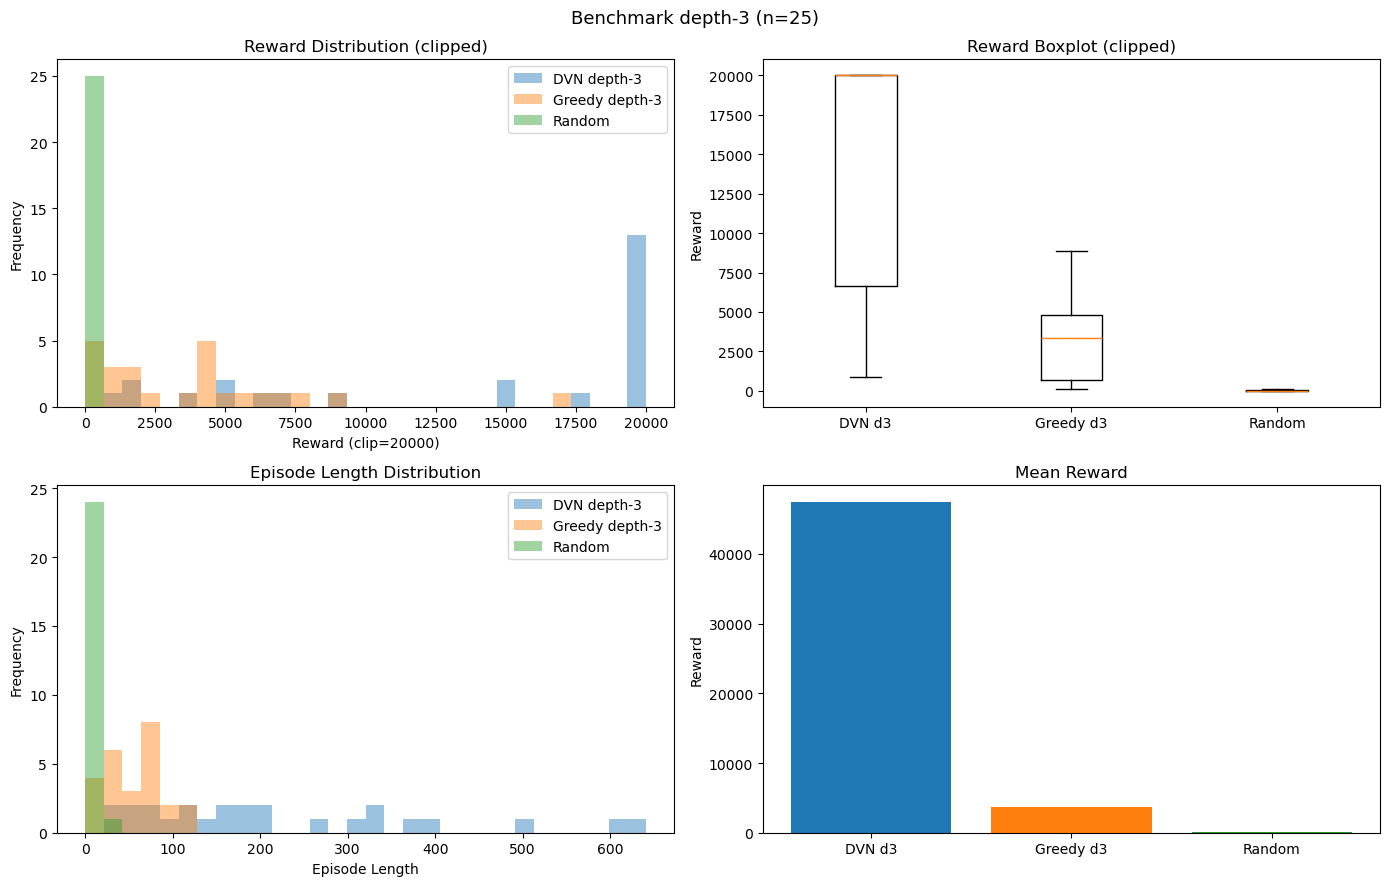

In [20]:
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

dvn3_plot = np.clip(dvn3_returns, 0, PLOT_CAP)
g3_plot = np.clip(g3_returns, 0, PLOT_CAP)
rnd3_plot = np.clip(rnd3_returns, 0, PLOT_CAP)

reward_bins = np.linspace(0, PLOT_CAP, 31)
length_max = max(int(np.max(dvn3_lengths)), int(np.max(g3_lengths)), int(np.max(rnd3_lengths)))
length_bins = np.linspace(0, length_max, 31)

ax = axes[0, 0]
ax.hist(dvn3_plot, bins=reward_bins, alpha=0.45, label='DVN depth-3')
ax.hist(g3_plot, bins=reward_bins, alpha=0.45, label='Greedy depth-3')
ax.hist(rnd3_plot, bins=reward_bins, alpha=0.45, label='Random')
ax.set_title('Reward Distribution (clipped)')
ax.set_xlabel(f'Reward (clip={PLOT_CAP})')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[0, 1]
ax.boxplot([dvn3_plot, g3_plot, rnd3_plot], tick_labels=['DVN d3', 'Greedy d3', 'Random'], showfliers=False)
ax.set_title('Reward Boxplot (clipped)')
ax.set_ylabel('Reward')

ax = axes[1, 0]
ax.hist(dvn3_lengths, bins=length_bins, alpha=0.45, label='DVN depth-3')
ax.hist(g3_lengths, bins=length_bins, alpha=0.45, label='Greedy depth-3')
ax.hist(rnd3_lengths, bins=length_bins, alpha=0.45, label='Random')
ax.set_title('Episode Length Distribution')
ax.set_xlabel('Episode Length')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1, 1]
means = [float(np.mean(dvn3_returns)), float(np.mean(g3_returns)), float(np.mean(rnd3_returns))]
labels = ['DVN d3', 'Greedy d3', 'Random']
ax.bar(labels, means, color=['C0', 'C1', 'C2'])
ax.set_title('Mean Reward')
ax.set_ylabel('Reward')

plt.suptitle(f'Benchmark depth-3 (n={EPISODES_D3})', fontsize=13)
plt.tight_layout()

fig_d3 = out_dir / f'benchmark_3p_clean_d3_{timestamp}.png'
plt.savefig(fig_d3, dpi=150)
print(f'Saved: {fig_d3}')
plt.show()

Saved: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_d3_unclipped_20260315_163056.png


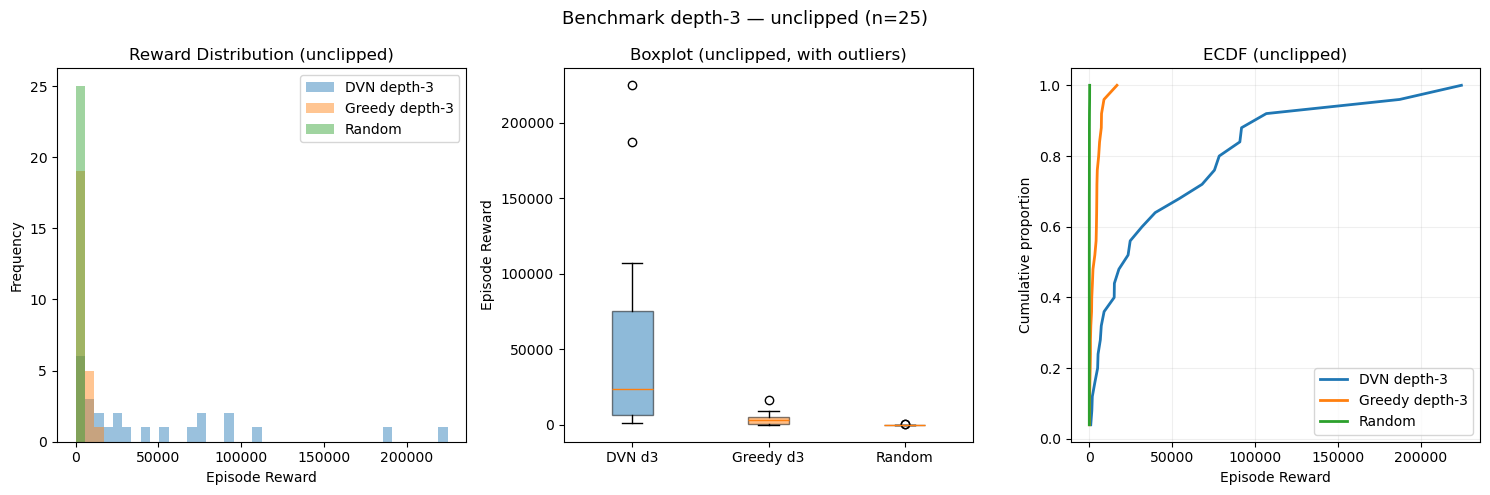

In [21]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

all_d3 = np.concatenate([dvn3_returns, g3_returns, rnd3_returns])
bins_unc3 = np.linspace(float(all_d3.min()), float(all_d3.max()), 41)

ax = axes[0]
ax.hist(dvn3_returns, bins=bins_unc3, alpha=0.45, label='DVN depth-3', color='C0')
ax.hist(g3_returns, bins=bins_unc3, alpha=0.45, label='Greedy depth-3', color='C1')
ax.hist(rnd3_returns, bins=bins_unc3, alpha=0.45, label='Random', color='C2')
ax.set_title('Reward Distribution (unclipped)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1]
bp = ax.boxplot(
    [dvn3_returns, g3_returns, rnd3_returns],
    tick_labels=['DVN d3', 'Greedy d3', 'Random'],
    showfliers=True,
    patch_artist=True,
)
for box, color in zip(bp['boxes'], ['C0', 'C1', 'C2']):
    box.set_facecolor(color)
    box.set_alpha(0.5)
ax.set_title('Boxplot (unclipped, with outliers)')
ax.set_ylabel('Episode Reward')

ax = axes[2]
x3u, y3u = ecdf(dvn3_returns)
xg3u, yg3u = ecdf(g3_returns)
xr3u, yr3u = ecdf(rnd3_returns)
ax.plot(x3u, y3u, label='DVN depth-3', linewidth=2, color='C0')
ax.plot(xg3u, yg3u, label='Greedy depth-3', linewidth=2, color='C1')
ax.plot(xr3u, yr3u, label='Random', linewidth=2, color='C2')
ax.set_title('ECDF (unclipped)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Cumulative proportion')
ax.grid(alpha=0.2)
ax.legend()

plt.suptitle(f'Benchmark depth-3 — unclipped (n={EPISODES_D3})', fontsize=13)
plt.tight_layout()

fig_d3_unc = out_dir / f'benchmark_3p_clean_d3_unclipped_{timestamp}.png'
plt.savefig(fig_d3_unc, dpi=150)
print(f'Saved: {fig_d3_unc}')
plt.show()


In [22]:
def _metrics(arr):
    q25, q50, q75 = np.percentile(arr, [25, 50, 75])
    return {
        'n':      len(arr),
        'mean':   float(np.mean(arr)),
        'std':    float(np.std(arr)),
        'var':    float(np.var(arr)),
        'min':    float(np.min(arr)),
        'p5':     float(np.percentile(arr, 5)),
        'p25':    float(q25),
        'median': float(q50),
        'p75':    float(q75),
        'p95':    float(np.percentile(arr, 95)),
        'max':    float(np.max(arr)),
        'iqr':    float(q75 - q25),
        'cv':     float(np.std(arr) / np.mean(arr)) if np.mean(arr) != 0 else float('nan'),
    }

_METRIC_KEYS = ['n', 'mean', 'std', 'var', 'min', 'p5', 'p25', 'median', 'p75', 'p95', 'max', 'iqr', 'cv']
_COL = 16

def _print_table(section_label, policies):
    print(f'\n{"=" * 70}')
    print(f'  {section_label}')
    print(f'{"=" * 70}')
    names = [name for name, _, _ in policies]
    header = f"{'metric':<10}" + ''.join(f"{n:>{_COL}}" for n in names)
    print(header)
    print('-' * len(header))
    reward_m = {name: _metrics(r) for name, r, _ in policies}
    for k in _METRIC_KEYS:
        row = f"{k:<10}" + ''.join(f"{reward_m[name][k]:>{_COL}.2f}" for name in names)
        print(row)
    print(f"\n{'metric (len)':<10}" + ''.join(f"{n:>{_COL}}" for n in names))
    print('-' * len(header))
    len_m = {name: _metrics(l) for name, _, l in policies}
    for k in ['mean', 'std', 'min', 'median', 'max']:
        row = f"{k:<10}" + ''.join(f"{len_m[name][k]:>{_COL}.2f}" for name in names)
        print(row)

_print_table(
    f'Benchmark 1 — depth-2  (n={EPISODES_MAIN} episodes)',
    [('DVN depth-2', dvn_returns, dvn_lengths),
     ('Greedy depth-2', g2_returns, g2_lengths),
     ('Random', rnd_returns, rnd_lengths)],
)

_print_table(
    f'Benchmark 2 — depth-3  (n={EPISODES_D3} episodes)',
    [('DVN depth-3', dvn3_returns, dvn3_lengths),
     ('Greedy depth-3', g3_returns, g3_lengths),
     ('Random', rnd3_returns, rnd3_lengths)],
)



  Benchmark 1 — depth-2  (n=250 episodes)
metric         DVN depth-2  Greedy depth-2          Random
----------------------------------------------------------
n                   250.00          250.00          250.00
mean              23412.72         1884.90           25.33
std               30429.17         2860.58           42.92
var           925934528.00      8182893.50         1842.21
min                  30.90           10.70            0.40
p5                  529.68          155.74            0.70
p25                3944.55          464.23            1.00
median            11689.35          982.65           10.70
p75               29681.20         2165.70           31.35
p95               88812.78         5661.86          111.31
max              160272.80        29250.50          271.80
iqr               25736.65         1701.47           30.35
cv                    1.30            1.52            1.69

metric (len)     DVN depth-2  Greedy depth-2          Random
----------

## 3) Comparaison DVN depth-2 vs DVN depth-3

Saved: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_cmp_d2_vs_d3_20260315_163056.png


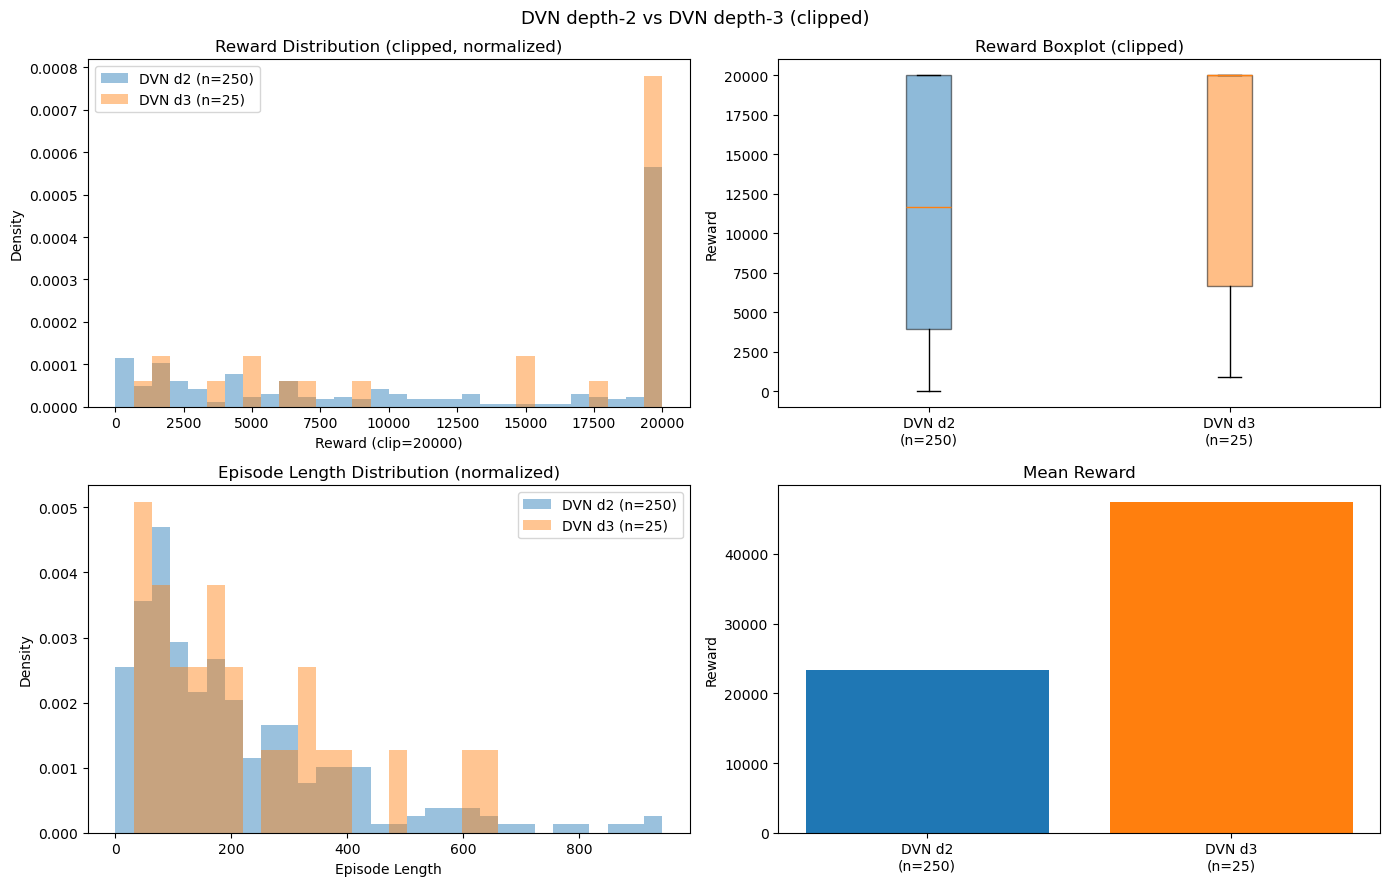

In [26]:
%matplotlib inline

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

dvn_cmp_plot  = np.clip(dvn_returns,  0, PLOT_CAP)
dvn3_cmp_plot = np.clip(dvn3_returns, 0, PLOT_CAP)

reward_bins = np.linspace(0, PLOT_CAP, 31)
length_max_cmp = max(int(np.max(dvn_lengths)), int(np.max(dvn3_lengths)))
length_bins_cmp = np.linspace(0, length_max_cmp, 31)

ax = axes[0, 0]
ax.hist(dvn_cmp_plot,  bins=reward_bins, alpha=0.45, label=f'DVN d2 (n={len(dvn_returns)})',  color='C0', density=True)
ax.hist(dvn3_cmp_plot, bins=reward_bins, alpha=0.45, label=f'DVN d3 (n={len(dvn3_returns)})', color='C1', density=True)
ax.set_title('Reward Distribution (clipped, normalized)')
ax.set_xlabel(f'Reward (clip={PLOT_CAP})')
ax.set_ylabel('Density')
ax.legend()

ax = axes[0, 1]
bp = ax.boxplot(
    [dvn_cmp_plot, dvn3_cmp_plot],
    tick_labels=[f'DVN d2\n(n={len(dvn_returns)})', f'DVN d3\n(n={len(dvn3_returns)})'],
    showfliers=False,
    patch_artist=True,
)
for box, color in zip(bp['boxes'], ['C0', 'C1']):
    box.set_facecolor(color)
    box.set_alpha(0.5)
ax.set_title('Reward Boxplot (clipped)')
ax.set_ylabel('Reward')

ax = axes[1, 0]
ax.hist(dvn_lengths,  bins=length_bins_cmp, alpha=0.45, label=f'DVN d2 (n={len(dvn_lengths)})',  color='C0', density=True)
ax.hist(dvn3_lengths, bins=length_bins_cmp, alpha=0.45, label=f'DVN d3 (n={len(dvn3_lengths)})', color='C1', density=True)
ax.set_title('Episode Length Distribution (normalized)')
ax.set_xlabel('Episode Length')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1, 1]
ax.bar(
    [f'DVN d2\n(n={len(dvn_returns)})', f'DVN d3\n(n={len(dvn3_returns)})'],
    [float(np.mean(dvn_returns)), float(np.mean(dvn3_returns))],
    color=['C0', 'C1'],
)
ax.set_title('Mean Reward')
ax.set_ylabel('Reward')

plt.suptitle('DVN depth-2 vs DVN depth-3 (clipped)', fontsize=13)
plt.tight_layout()

fig_cmp = out_dir / f'benchmark_3p_clean_cmp_d2_vs_d3_{timestamp}.png'
plt.savefig(fig_cmp, dpi=150)
print(f'Saved: {fig_cmp}')
plt.show()


## 3b) DVN depth-2 vs DVN depth-3 — sans clipping

Saved: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_cmp_d2_vs_d3_unclipped_20260315_163056.png


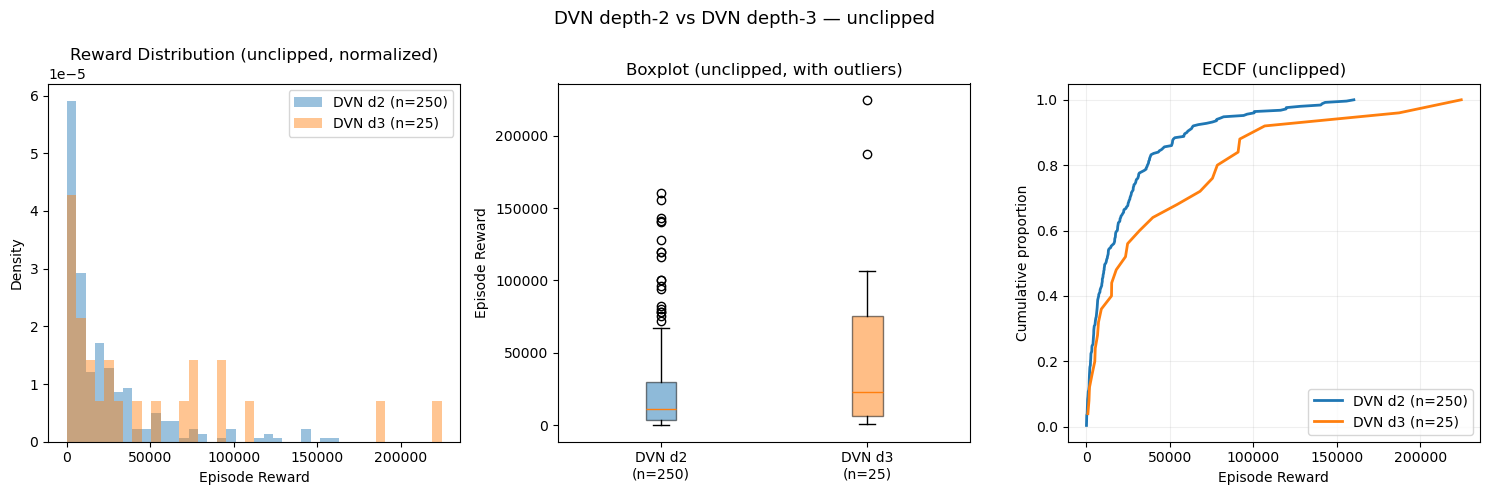

In [27]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

all_cmp = np.concatenate([dvn_returns, dvn3_returns])
bins_cmp_unc = np.linspace(float(all_cmp.min()), float(all_cmp.max()), 41)

ax = axes[0]
ax.hist(dvn_returns,  bins=bins_cmp_unc, alpha=0.45, label=f'DVN d2 (n={len(dvn_returns)})',  color='C0', density=True)
ax.hist(dvn3_returns, bins=bins_cmp_unc, alpha=0.45, label=f'DVN d3 (n={len(dvn3_returns)})', color='C1', density=True)
ax.set_title('Reward Distribution (unclipped, normalized)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
bp = ax.boxplot(
    [dvn_returns, dvn3_returns],
    tick_labels=[f'DVN d2\n(n={len(dvn_returns)})', f'DVN d3\n(n={len(dvn3_returns)})'],
    showfliers=True,
    patch_artist=True,
)
for box, color in zip(bp['boxes'], ['C0', 'C1']):
    box.set_facecolor(color)
    box.set_alpha(0.5)
ax.set_title('Boxplot (unclipped, with outliers)')
ax.set_ylabel('Episode Reward')

ax = axes[2]
ax.plot(*ecdf(dvn_returns),  label=f'DVN d2 (n={len(dvn_returns)})',  linewidth=2, color='C0')
ax.plot(*ecdf(dvn3_returns), label=f'DVN d3 (n={len(dvn3_returns)})', linewidth=2, color='C1')
ax.set_title('ECDF (unclipped)')
ax.set_xlabel('Episode Reward')
ax.set_ylabel('Cumulative proportion')
ax.grid(alpha=0.2)
ax.legend()

plt.suptitle('DVN depth-2 vs DVN depth-3 — unclipped', fontsize=13)
plt.tight_layout()

fig_cmp_unc = out_dir / f'benchmark_3p_clean_cmp_d2_vs_d3_unclipped_{timestamp}.png'
plt.savefig(fig_cmp_unc, dpi=150)
print(f'Saved: {fig_cmp_unc}')
plt.show()


In [25]:
# Persist raw arrays so comparisons can be reproduced without rerun
npz_path = out_dir / f'benchmark_3p_clean_data_{timestamp}.npz'
np.savez_compressed(
    npz_path,
    dvn_returns=dvn_returns,
    dvn_lengths=dvn_lengths,
    g2_returns=g2_returns,
    g2_lengths=g2_lengths,
    rnd_returns=rnd_returns,
    rnd_lengths=rnd_lengths,
    dvn3_returns=dvn3_returns,
    dvn3_lengths=dvn3_lengths,
    g3_returns=g3_returns,
    g3_lengths=g3_lengths,
    rnd3_returns=rnd3_returns,
    rnd3_lengths=rnd3_lengths,
    episodes_main=np.array([EPISODES_MAIN], dtype=np.int32),
    episodes_d3=np.array([EPISODES_D3], dtype=np.int32),
    gamma=np.array([GAMMA], dtype=np.float32),
    seed=np.array([SEED], dtype=np.int32),
)
print(f'Saved data: {npz_path}')

Saved data: /users/eleves-a/2023/arthur.paing/Documents/RL/RL_project/plots/benchmark_3p_clean_data_20260315_163056.npz
